# Monte Carlo Convergence to Black Scholes

This plot shows how the Monte Carlo estimated price converges to the closed form Black Scholes price as the number of simulations N increases, from 100 to 100,000. The x axis uses a logarithmic scale, since N spans several orders of magnitude, and a linear scale would compress the low N points into an unreadable cluster.

As N increases, the Monte Carlo estimate converges toward the true price, consistent with the Law of Large Numbers: averaging more independent random samples brings the sample mean closer to the true expected value.

$$S_T = S_0 \, e^{(r - \sigma^2/2)T + \sigma\sqrt{T}\,Z}, \quad Z \sim N(0,1)$$

The expected error shrinks and the estimate becomes more reliable, but convergence happens in expectation rather than step by step, so any individual run can still fluctuate slightly due to randomness. This is visible in the small overshoot around N equals 1000 to 5000 before the estimate settles.

The rate of convergence follows the relationship below, meaning a hundredfold increase in simulations only reduces the expected error by roughly tenfold. This is why the largest accuracy gains happen early, between N equals 100 and 1000, while further increases yield diminishing returns.

$$\text{Standard Error} \propto \frac{1}{\sqrt{N}}$$

In [7]:
import os 
os.chdir("..")
print(os.getcwd())

c:\Users\chris\OneDrive\Documents\DOC ADMIN\Quant Finance start\option-pricing-engine


In [ ]:
import numpy as np
from src.option import Option
from src.monte_carlo import monte_carlo_price
from src.black_scholes import black_scholes_price

call = Option(S=100, K=100, T=1, r=0.05, sigma=0.2, option_type="call")
bs_price = black_scholes_price(call)

N_values = [100, 500, 1000, 5000, 10000, 50000, 100000]
mc_prices = []

for n in N_values:
    np.random.seed(42) 
    price = monte_carlo_price(call, num_simulations=n)
    mc_prices.append(price)




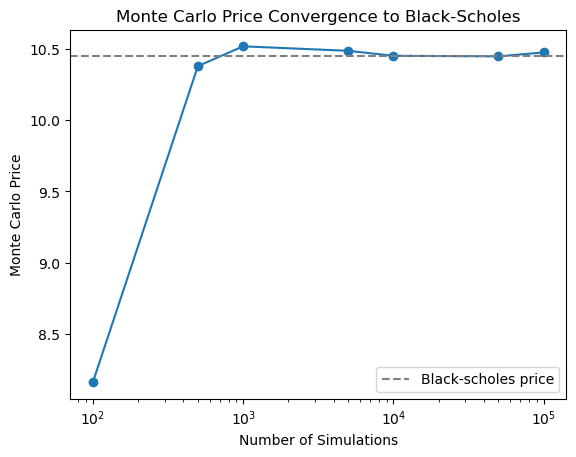

In [18]:
import matplotlib.pyplot as plt
plt.plot(N_values, mc_prices, marker='o')
plt.axhline(bs_price, color='grey', linestyle='--', label='Black-scholes price' )
plt.xscale('log')
plt.xlabel('Number of Simulations')
plt.ylabel('Monte Carlo Price')
plt.title('Monte Carlo Price Convergence to Black-Scholes')
plt.legend()
plt.show()

# Volatility Sensitivity

This plot shows how call and put prices respond to changes in volatility, holding the spot price, strike, time to maturity, and risk free rate fixed.

$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

$$C = S_0 N(d_1) - K e^{-rT} N(d_2)$$
$$P = K e^{-rT} N(-d_2) - S_0 N(-d_1)$$

Both curves slope upward, meaning higher volatility increases the price of both calls and puts. This follows directly from the payoff structure: an option's downside is floored at zero, but its upside is unbounded. Higher volatility widens the range of possible outcomes at expiration, which adds value on the favorable side of the payoff without adding any extra cost on the unfavorable side, since losses beyond the floor are never realized. This holds symmetrically for calls, which are protected from extra downside, and puts, which are protected from extra upside, which is why both lines rise together rather than moving in opposite directions.

In Black Scholes terms, this sensitivity is known as Vega, and it is positive for both calls and puts.

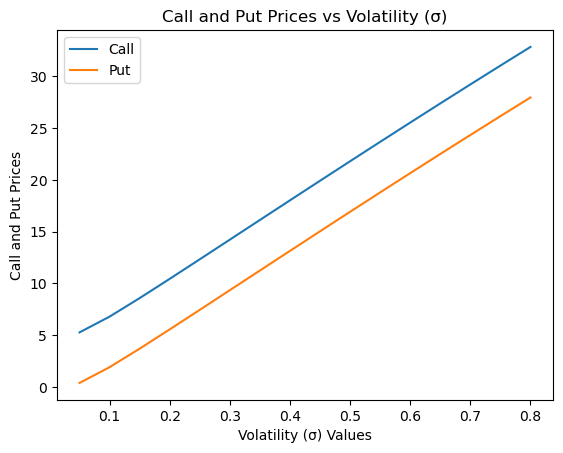

In [ ]:
K_values = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

call_values = []
put_values = []

for i in K_values :
    call = Option(S=100, K=100, T=1, r=0.05, sigma=i, option_type="call")
    call_values.append(black_scholes_price(call))

    put = Option(S=100, K=100, T=1, r=0.05, sigma=i, option_type="put")
    put_values.append(black_scholes_price(put))

plt.plot(K_values, call_values, label='Call')
plt.plot(K_values, put_values, label='Put')

plt.xlabel('Volatility (σ) Values')
plt.ylabel('Call and Put Prices')

plt.title('Call and Put Prices vs Volatility (σ)')
plt.legend()
plt.show()




# Strike Sensitivity

This plot shows how call and put prices change as the strike price varies, holding the spot price, time to maturity, risk free rate, and volatility fixed, with the spot price set at 100.

$$\text{Call payoff} = \max(S_T - K, 0), \qquad \text{Put payoff} = \max(K - S_T, 0)$$

The call price decreases as the strike increases. A call at a low strike is deep in the money, since it is cheap to exercise relative to the stock price, while a call at a high strike becomes increasingly unlikely to pay off. The put price shows the mirror image behavior, increasing as the strike rises, since a higher strike makes it more likely the holder can sell above the market price.

The two curves cross near the point where the strike equals the spot price, close to the at the money point, where call and put values converge. The slight offset from exactly 100 reflects the risk free rate's effect on the forward price.

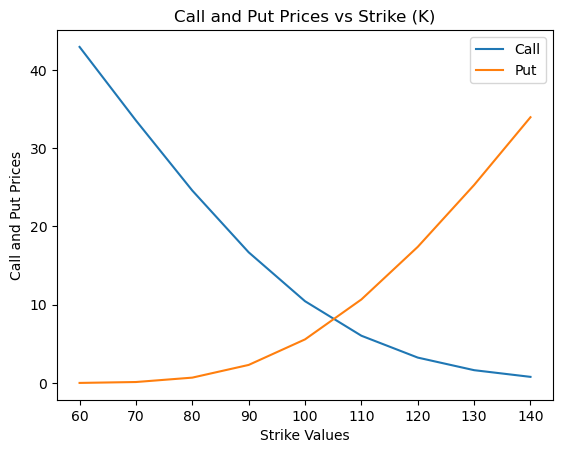

In [ ]:
K_values = [60, 70, 80, 90, 100, 110, 120, 130, 140]

call_values = []
put_values = []

for i in K_values :
    call = Option(S=100, K=i, T=1, r=0.05, sigma=0.2, option_type="call")
    call_values.append(black_scholes_price(call))

    put = Option(S=100, K=i, T=1, r=0.05, sigma=0.2, option_type="put")
    put_values.append(black_scholes_price(put))

plt.plot(K_values, call_values, label='Call')
plt.plot(K_values, put_values, label='Put')

plt.xlabel('Strike Values')
plt.ylabel('Call and Put Prices')

plt.title('Call and Put Prices vs Strike (K)')
plt.legend()
plt.show()




# Put Call Parity Verification

Put call parity is a no arbitrage relationship that must hold for any European call and put sharing the same spot price, strike, time to maturity, and risk free rate.

$$C - P = S_0 - Ke^{-rT}$$

Notably, volatility does not appear in this formula, so the relationship should hold regardless of volatility. This check confirms that across multiple combinations of strike (80, 100, and 120) and volatility (0.1, 0.2, and 0.3), the computed left hand side matches the right hand side exactly, and as expected, the right hand side stays constant across all volatility values for a given strike, since volatility has no effect on it.

This serves as an internal consistency check on the Black Scholes implementation. It confirms the pricer respects a fundamental arbitrage free relationship, independent of the specific formula's derivation.

In [31]:
import math 

K_values_test = [80, 100, 120]
sigma_values_test = [0.1, 0.2, 0.3]

for k in K_values_test:
    for s in sigma_values_test:
        call = Option(S=100, K=k, T=1, r=0.05, sigma=s, option_type="call")
        put = Option(S=100, K=k, T=1, r=0.05, sigma=s, option_type="put")

        C = black_scholes_price(call)
        P = black_scholes_price(put)

        left_side = C - P
        right_side = call.spot_price - (call.strike_price * math.exp(-1 * call.risk_free_rate * call.time_to_maturity))

        print(f"K={k}, sigma={s}: C-P = {left_side:.4f}, S-Ke^-rT = {right_side:.4f}")



K=80, sigma=0.1: C-P = 23.9016, S-Ke^-rT = 23.9016
K=80, sigma=0.2: C-P = 23.9016, S-Ke^-rT = 23.9016
K=80, sigma=0.3: C-P = 23.9016, S-Ke^-rT = 23.9016
K=100, sigma=0.1: C-P = 4.8771, S-Ke^-rT = 4.8771
K=100, sigma=0.2: C-P = 4.8771, S-Ke^-rT = 4.8771
K=100, sigma=0.3: C-P = 4.8771, S-Ke^-rT = 4.8771
K=120, sigma=0.1: C-P = -14.1475, S-Ke^-rT = -14.1475
K=120, sigma=0.2: C-P = -14.1475, S-Ke^-rT = -14.1475
K=120, sigma=0.3: C-P = -14.1475, S-Ke^-rT = -14.1475
